In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

## **MODEL TRAINING**
---


In [67]:
df=pd.read_csv("restaurant_data.csv")

In [68]:
df.head()


,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
0,Restaurant 0,Rural,Japanese,4.0,38,73.98,2224,23406,13,185,161.924906,1.3,7.0,Yes,13,4,638945.52
1,Restaurant 1,Downtown,Mexican,3.2,76,28.11,4416,42741,8,533,148.759717,2.6,3.4,Yes,48,6,490207.83
2,Restaurant 2,Rural,Italian,4.7,48,48.29,2796,37285,18,853,56.849189,5.3,6.7,No,27,14,541368.62
3,Restaurant 3,Rural,Italian,4.4,34,51.55,1167,15214,13,82,205.433265,4.6,2.8,Yes,9,17,404556.80
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35


In [69]:
df.tail()

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
8363,Restaurant 8363,Suburban,Indian,3.4,54,34.85,1102,11298,11,380,253.919515,9.5,5.0,Yes,37,0,434653.45
8364,Restaurant 8364,Rural,Indian,3.7,49,36.88,1988,20432,9,713,175.590195,2.7,2.6,No,37,21,414977.92
8365,Restaurant 8365,Downtown,Italian,4.7,88,46.87,5949,63945,6,436,222.953647,4.8,1.7,Yes,83,21,930395.87
8366,Restaurant 8366,Rural,American,3.1,31,44.53,707,7170,1,729,178.482851,6.1,2.1,No,6,21,311493.48
8367,Restaurant 8367,Rural,Japanese,4.0,33,71.07,2003,24268,8,197,151.838065,5.9,7.5,Yes,5,12,534142.98


In [70]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8368 entries, 0 to 8367
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    8368 non-null   str    
 1   Location                8368 non-null   str    
 2   Cuisine                 8368 non-null   str    
 3   Rating                  8368 non-null   float64
 4   Seating Capacity        8368 non-null   int64  
 5   Average Meal Price      8368 non-null   float64
 6   Marketing Budget        8368 non-null   int64  
 7   Social Media Followers  8368 non-null   int64  
 8   Chef Experience Years   8368 non-null   int64  
 9   Number of Reviews       8368 non-null   int64  
 10  Avg Review Length       8368 non-null   float64
 11  Ambience Score          8368 non-null   float64
 12  Service Quality Score   8368 non-null   float64
 13  Parking Availability    8368 non-null   str    
 14  Weekend Reservations    8368 non-null   int64  
 15

,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Weekend Reservations,Weekday Reservations,Revenue
count,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8.368000e+03
mean,4.008258,60.212835,47.896659,3218.254900,36190.621773,10.051984,523.010397,174.769974,5.521283,5.508772,29.491754,29.235301,6.560706e+05
std,0.581474,17.399488,14.336767,1824.896053,18630.153330,5.516606,277.215127,71.998060,2.575442,2.586552,20.025415,20.004277,2.674137e+05
min,3.000000,30.000000,25.000000,604.000000,5277.000000,1.000000,50.000000,50.011717,1.000000,1.000000,0.000000,0.000000,1.847085e+05
25%,3.500000,45.000000,35.490000,1889.000000,22592.500000,5.000000,277.000000,113.311102,3.300000,3.200000,13.000000,13.000000,4.546514e+05
50%,4.000000,60.000000,45.535000,2846.500000,32518.500000,10.000000,528.000000,173.910079,5.500000,5.600000,27.000000,26.000000,6.042421e+05
75%,4.500000,75.000000,60.300000,4008.500000,44566.250000,15.000000,764.250000,237.406885,7.800000,7.800000,43.000000,43.000000,8.130942e+05
max,5.000000,90.000000,76.000000,9978.000000,103777.000000,19.000000,999.000000,299.984924,10.000000,10.000000,88.000000,88.000000,1.531868e+06


#### **a. Missing data checking and handling**

---

In [71]:
missing_count= df.isnull().sum()
print("Total Missing values:",missing_count)

Total Missing values: Name                      0
Location                  0
Cuisine                   0
Rating                    0
Seating Capacity          0
Average Meal Price        0
Marketing Budget          0
Social Media Followers    0
Chef Experience Years     0
Number of Reviews         0
Avg Review Length         0
Ambience Score            0
Service Quality Score     0
Parking Availability      0
Weekend Reservations      0
Weekday Reservations      0
Revenue                   0
dtype: int64


#### *b. Duplicate data checking and handling*  
#### *i. Dropping duplicate rows* 

---

In [72]:
duplicate_count = df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 0


#### **ii. Unique value checking and replacing any possible entity**

---

In [73]:
cols={'Name', 'Location', 'Cuisine', 'Rating', 'Seating Capacity',
       'Average Meal Price', 'Marketing Budget', 'Social Media Followers',
       'Chef Experience Years', 'Number of Reviews', 'Avg Review Length',
       'Ambience Score', 'Service Quality Score', 'Parking Availability',
       'Weekend Reservations', 'Weekday Reservations'}
for i in cols:
    print(i,":")
    print(df[i].unique())


Seating Capacity :
[38 76 48 34 88 79 49 61 37 32 40 77 42 59 87 56 60 72 53 57 75 82 41 35
 68 64 31 46 45 74 71 84 33 51 54 67 70 89 55 83 39 47 58 81 63 80 69 78
 43 85 50 90 52 44 36 30 65 86 73 62 66]
Rating :
[4.  3.2 4.7 4.4 4.9 4.1 4.2 5.  4.3 3.1 4.8 4.6 3.6 3.3 3.4 3.5 3.7 3.8
 4.5 3.  3.9]
Name :
<StringArray>
[   'Restaurant 0',    'Restaurant 1',    'Restaurant 2',    'Restaurant 3',
    'Restaurant 4',    'Restaurant 5',    'Restaurant 6',    'Restaurant 7',
    'Restaurant 8',    'Restaurant 9',
 ...
 'Restaurant 8358', 'Restaurant 8359', 'Restaurant 8360', 'Restaurant 8361',
 'Restaurant 8362', 'Restaurant 8363', 'Restaurant 8364', 'Restaurant 8365',
 'Restaurant 8366', 'Restaurant 8367']
Length: 8368, dtype: str
Parking Availability :
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
Average Meal Price :
[73.98 28.11 48.29 ... 72.06 53.63 71.07]
Service Quality Score :
[ 7.   3.4  6.7  2.8  2.1  8.5  5.3  4.6  9.4  7.4  7.1  2.7  2.9  6.9
  1.6  8.   9.5  4.7  3.3  9.3

#### **c. Encoding approach [Categorical features only]**

---

In [74]:
##can do using scikit learn
df_encoded = df.copy()

categorical_cols = df_encoded.select_dtypes(include=['object']).columns
print("Categorical Columns:", list(categorical_cols))

df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)
df_encoded.astype(int).head()

Categorical Columns: ['Name', 'Location', 'Cuisine', 'Parking Availability']


C:\Users\shtsu\AppData\Local\Temp\ipykernel_17732\3791111660.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_encoded.select_dtypes(include=['object']).columns


,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,...,Name_Restaurant 998,Name_Restaurant 999,Location_Rural,Location_Suburban,Cuisine_French,Cuisine_Indian,Cuisine_Italian,Cuisine_Japanese,Cuisine_Mexican,Parking Availability_Yes
0,4,38,73,2224,23406,13,185,161,1,7,...,0,0,1,0,0,0,0,1,0,1
1,3,76,28,4416,42741,8,533,148,2,3,...,0,0,0,0,0,0,0,0,1,1
2,4,48,48,2796,37285,18,853,56,5,6,...,0,0,1,0,0,0,1,0,0,0
3,4,34,51,1167,15214,13,82,205,4,2,...,0,0,1,0,0,0,1,0,0,1
4,4,88,75,3639,40171,9,78,241,8,2,...,0,0,0,0,0,0,0,1,0,0


#### **d. Basic EDA**  
#### **i. Graph plotting for numeric and categorical feature and their explanation**   
#### **ii. Can add basic static analysis (use of describe  so can be used for further comparison after outlier handling)**  

---

In [75]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Data types
df.info()

Shape of dataset: (8368, 17)
<class 'pandas.DataFrame'>
RangeIndex: 8368 entries, 0 to 8367
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    8368 non-null   str    
 1   Location                8368 non-null   str    
 2   Cuisine                 8368 non-null   str    
 3   Rating                  8368 non-null   float64
 4   Seating Capacity        8368 non-null   int64  
 5   Average Meal Price      8368 non-null   float64
 6   Marketing Budget        8368 non-null   int64  
 7   Social Media Followers  8368 non-null   int64  
 8   Chef Experience Years   8368 non-null   int64  
 9   Number of Reviews       8368 non-null   int64  
 10  Avg Review Length       8368 non-null   float64
 11  Ambience Score          8368 non-null   float64
 12  Service Quality Score   8368 non-null   float64
 13  Parking Availability    8368 non-null   str    
 14  Weekend Reservations  

### **NUMERIC FEATURE VISUALIZATION**
---

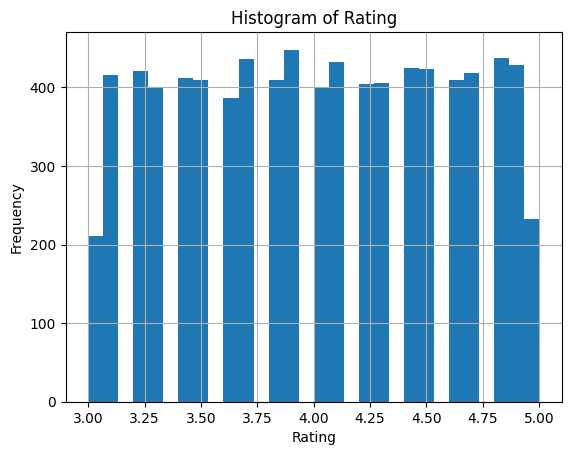

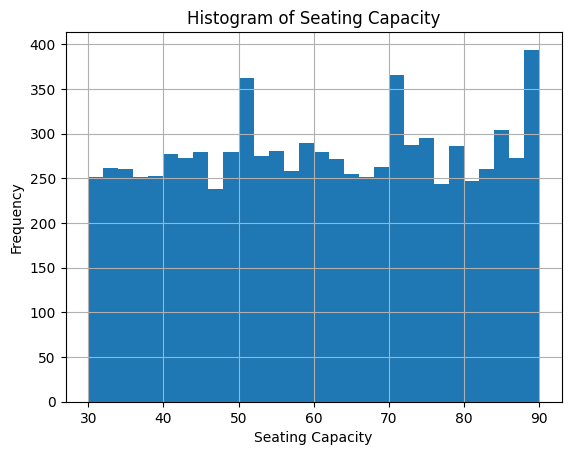

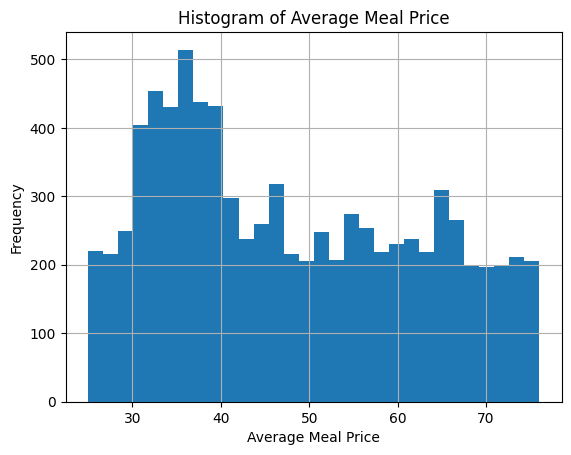

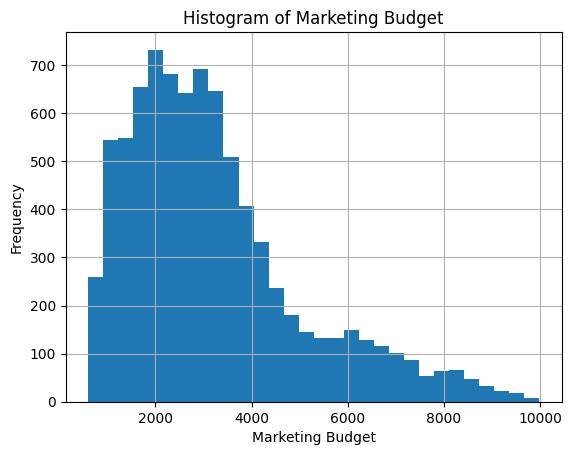

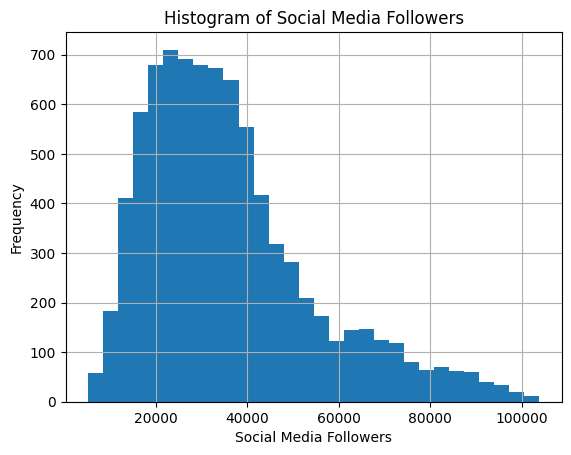

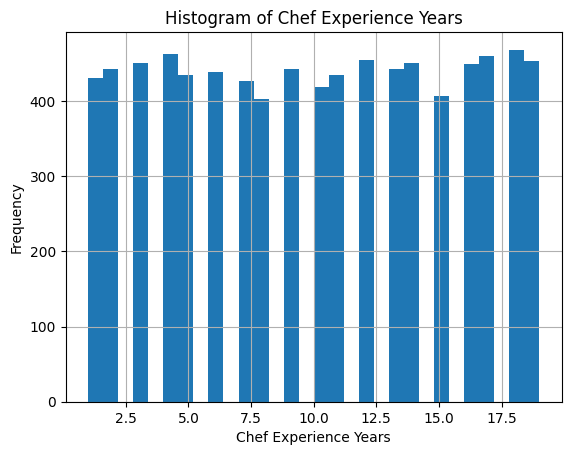

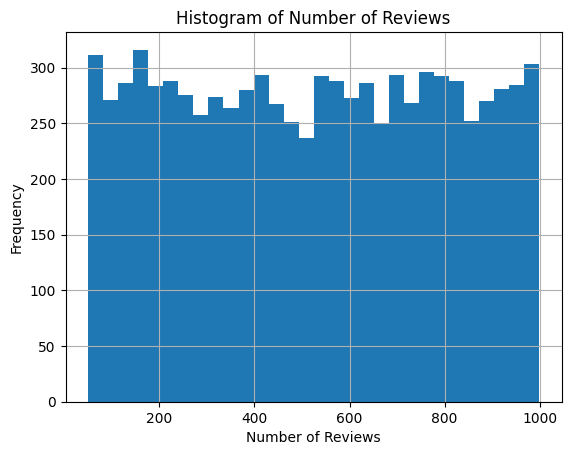

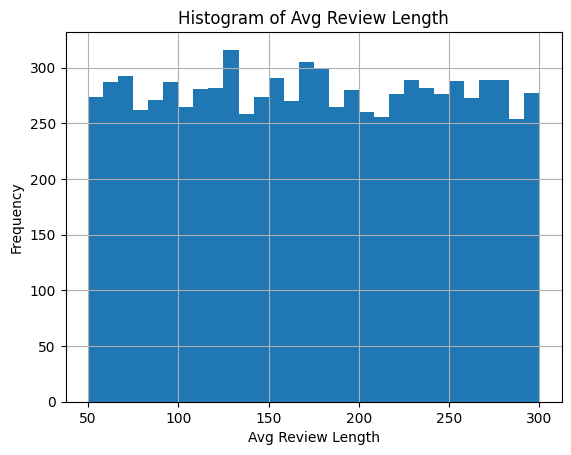

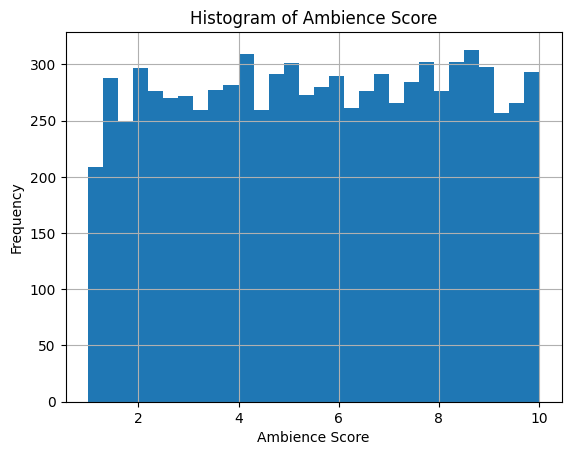

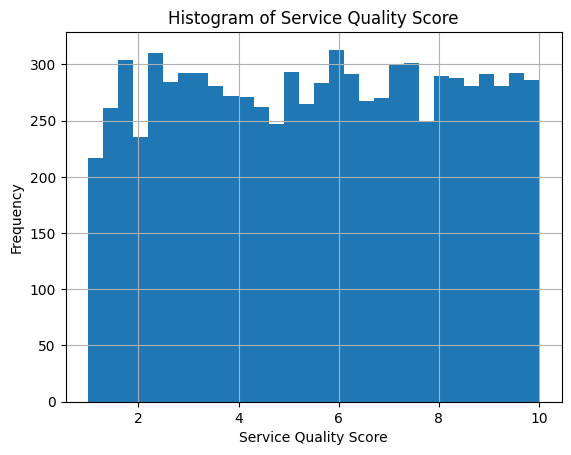

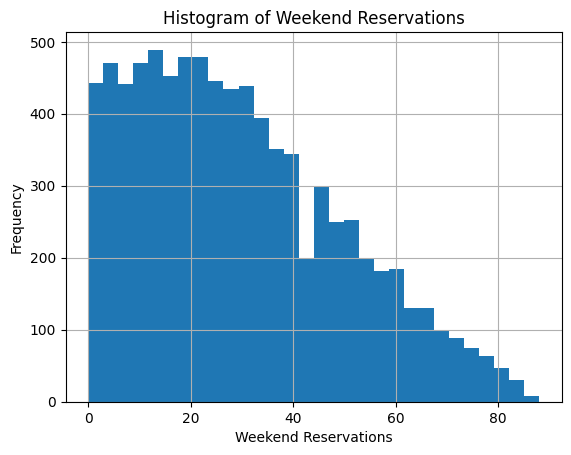

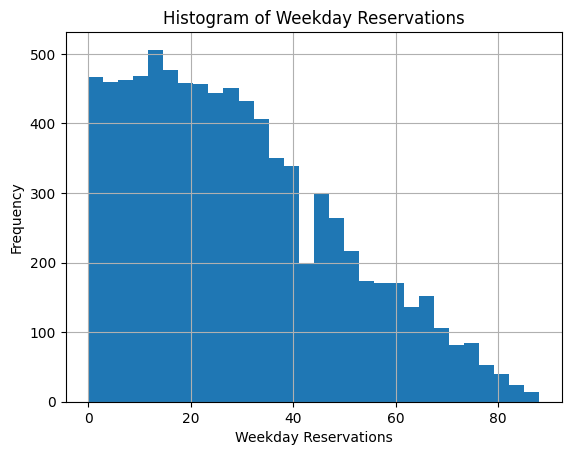

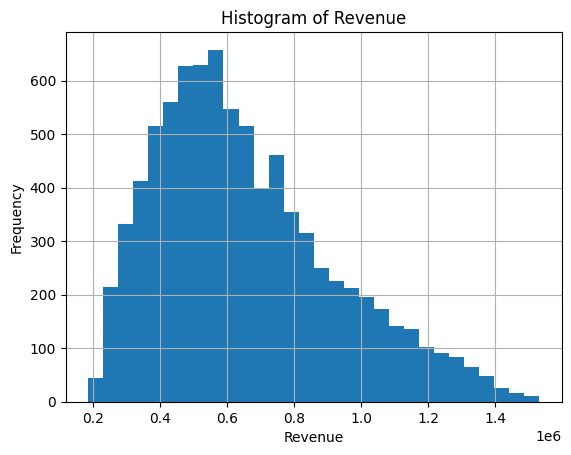

In [76]:
# Get numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Histogram for numeric features
for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

###  Insight: Numeric Feature Distributions (Histograms)

- **Revenue** — The right-skewed shape tells us that most restaurants earn a moderate income, while only a small number of high-performing restaurants generate significantly larger revenue. This means revenue inequality exists in the dataset 

- **Marketing Budget** — The right skew indicates that most restaurants invest modestly in marketing, with only a few spending aggressively. This suggests marketing is often underprioritized, and those who invest heavily may stand out competitively in the market.

- **Social Media Followers** — The right-skewed shape shows that most restaurants have a modest online presence, while a few have achieved viral popularity. This unequal distribution implies that social media success is concentrated among outliers rather than being evenly distributed.

- **Weekday Reservations** — The strong right skew reveals that most restaurants struggle to fill seats on weekdays, with very few managing consistent midweek traffic. This reflects how dining culture is typically weekend-driven.

- **Weekend Reservations** — Similar right skew as weekday but slightly more spread out. It confirms that even weekend demand is not evenly shared — a minority of restaurants capture most of the weekend foot traffic.


- **Seating Capacity** — The near-uniform shape tells us that restaurants of all sizes are equally represented in the dataset. No particular capacity dominates, meaning size alone is not a defining characteristic — its impact on revenue must be interpreted alongside other features.

- **Service Quality Score** — The flat, uniform distribution tells us that service quality varies widely and evenly across all restaurants. There is no "typical" service level, meaning this feature has strong discriminatory power.

- **Ambience Score** — Like service quality, the uniform distribution shows ambience is spread across all levels equally. 

- **Rating** — The near-uniform spread tells us that customer satisfaction does not cluster around one quality level. Every rating band is fairly represented, meaning rating interacts with other factors (like price, location) to influence revenue rather than acting as a standalone predictor.

- **Chef Experience Years** — The uniform distribution means the dataset has equal representation from novice to highly experienced chefs. This ensures the model can fairly learn how experience contributes to revenue without being biased toward any particular experience range.

- **Number of Reviews** — The flat distribution across all review counts suggests review volume is essentially random in this dataset. Rather than clustering around well-known or popular restaurants, it is evenly spread — which weakens it as a standalone predictor of revenue.

- **Avg Review Length** — The completely uniform shape shows that how much customers write in their reviews has no natural pattern. It does not correlate with restaurant engagement or quality, indicating this feature carries very little meaningful signal for revenue prediction.

### **CATEGORICAL FEATURE VISUALIZATION**
---

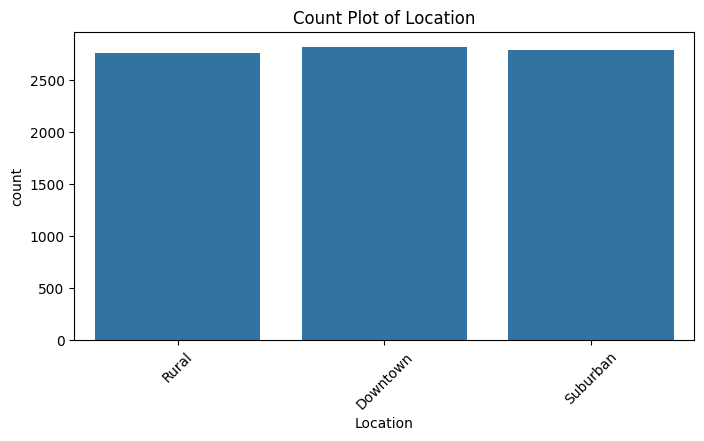

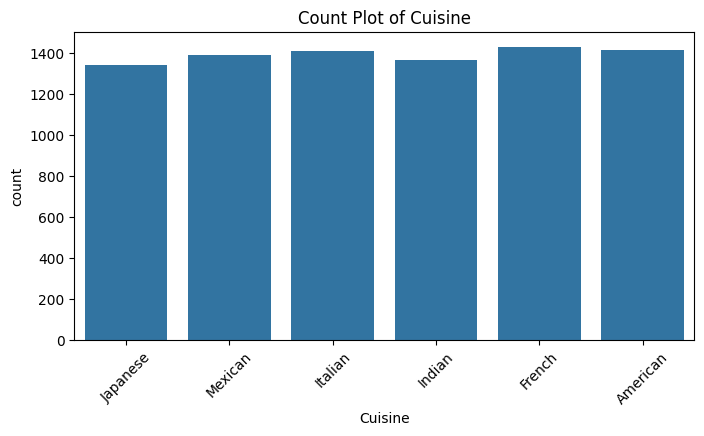

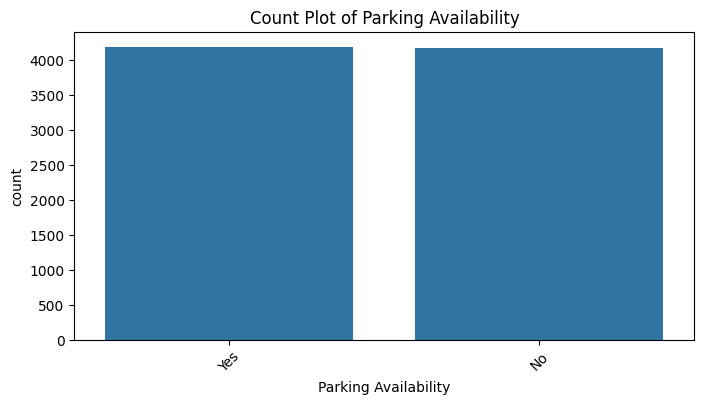

In [77]:
categorical_cols = [
    'Location',
    'Cuisine',
    'Parking Availability'
]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

### **CATEGORICAL FEATURE VS REVENUE VISUALIZATION**
---

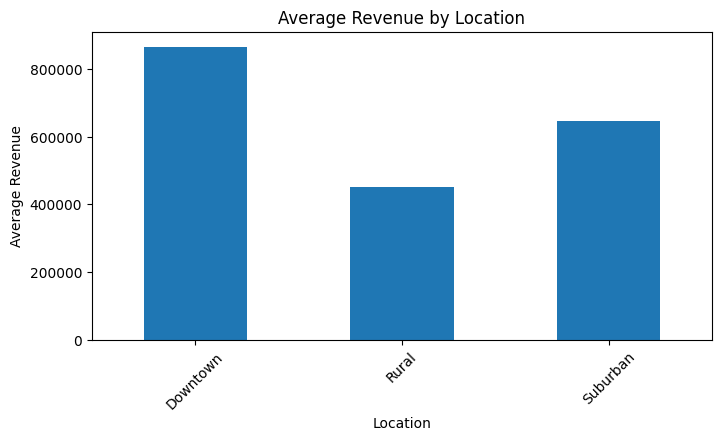

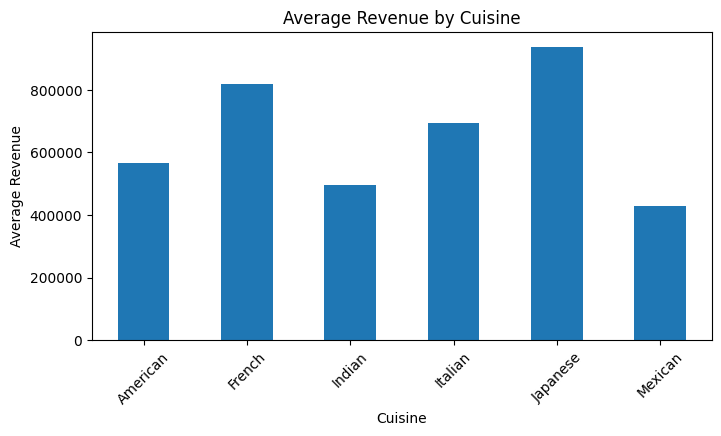

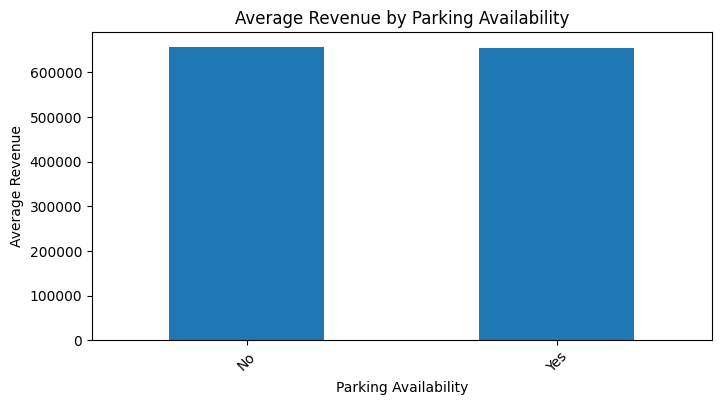

In [78]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df.groupby(col)['Revenue'].mean().plot(kind='bar')
    plt.title(f"Average Revenue by {col}")
    plt.ylabel("Average Revenue")
    plt.xticks(rotation=45)
    plt.show()

#### *e. Outlier handling [Numeric features only]* 
#### *i. Use boxplot of individual features for visualization.*
---
 

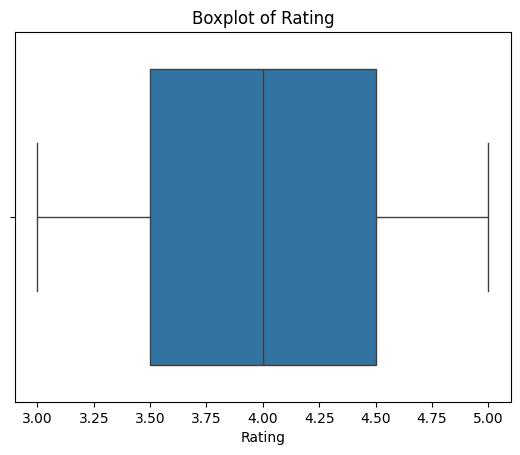

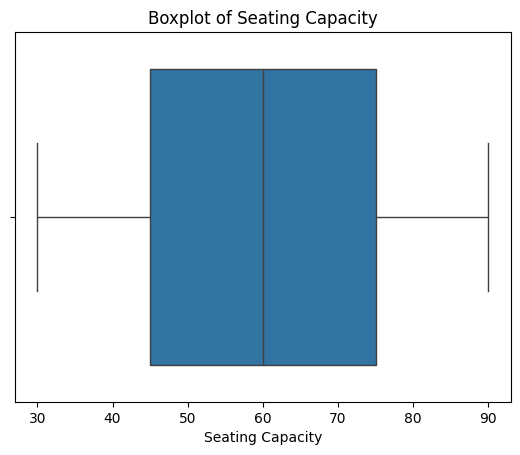

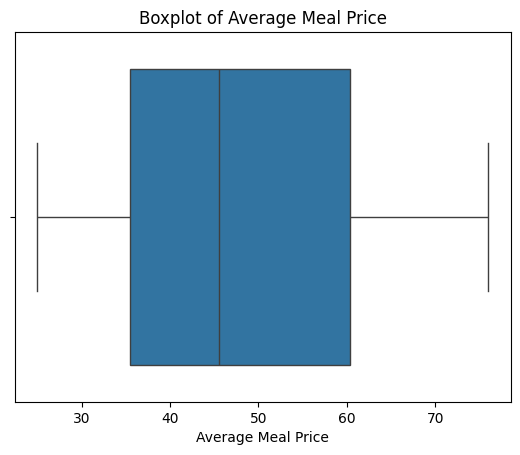

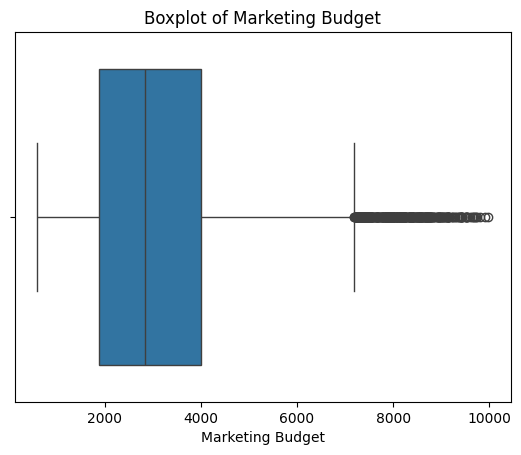

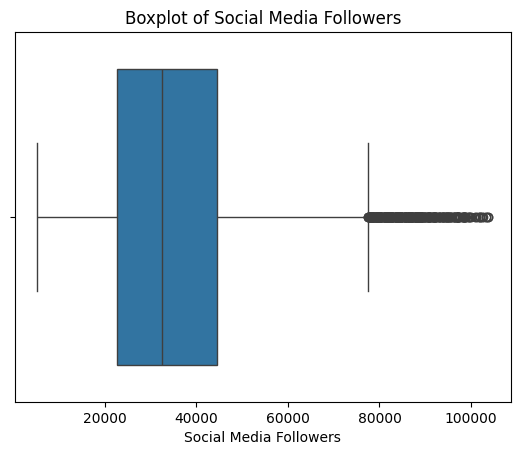

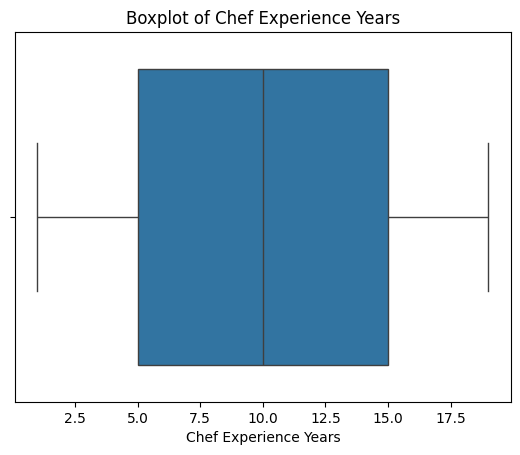

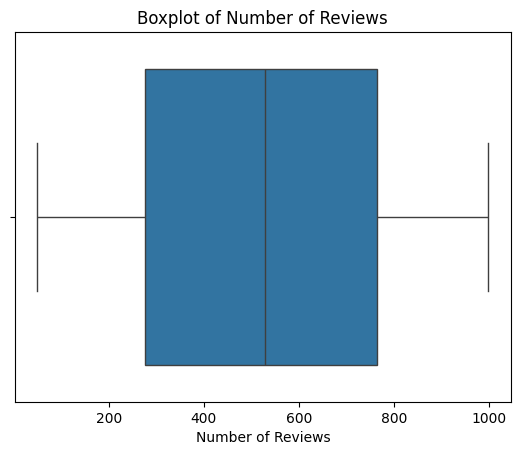

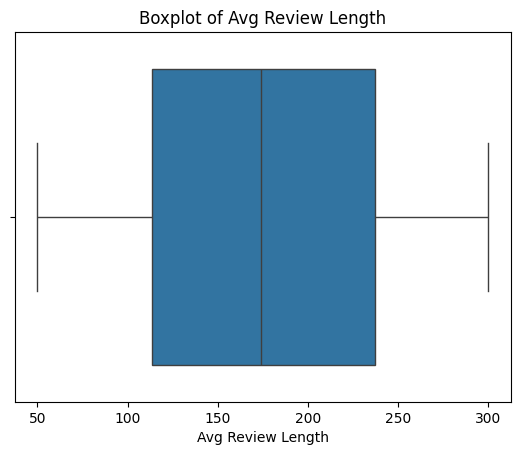

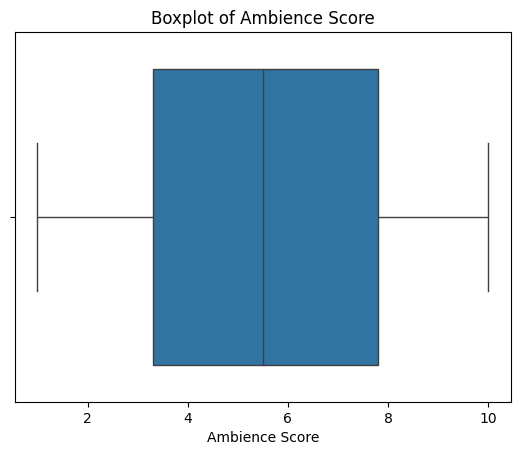

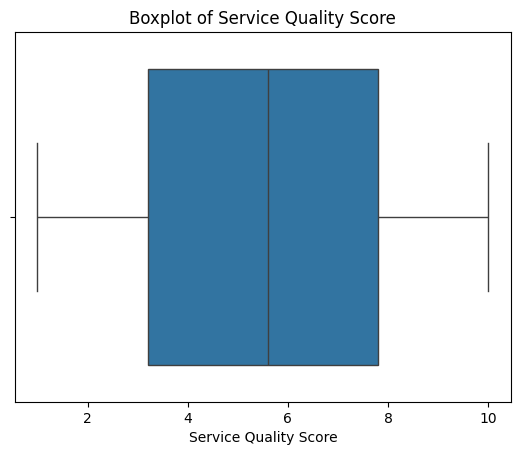

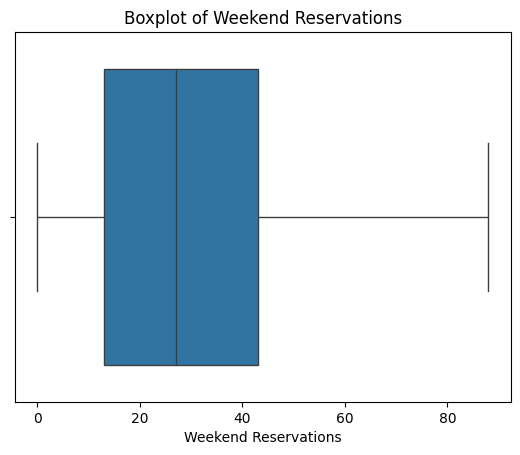

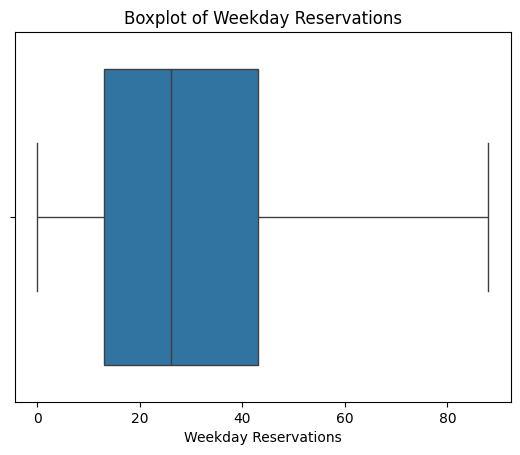

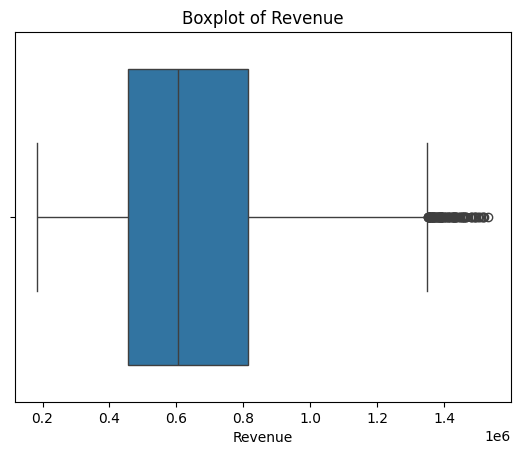

In [79]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

###  Insights from Boxplots

- **Revenue**: The shape shows a strong right-side stretch with many high-end outliers, meaning a small group of restaurants performs exceptionally better than the majority. This can bias model learning if untreated.

- **Weekday and Weekend Reservations**: Both shapes appear fairly balanced without major outlier clusters, which suggests reservation behavior is broadly stable across restaurants rather than dominated by extremes.

- **Service Quality Score and Ambience Score**: The spread is wide and symmetric, indicating these experience-related features are well distributed across low to high values and can meaningfully separate restaurant profiles.

- **Average Review Length and Number of Reviews**: The shapes are centered and balanced, indicating consistent variation without extreme review-behavior anomalies. These features look structurally stable.

- **Chef Experience Years**: The symmetric spread across the range indicates balanced representation of both less-experienced and highly experienced chefs, reducing sampling bias for this feature.

- **Social Media Followers and Marketing Budget**: These show clear right-tail outliers, which means a few restaurants have exceptionally high digital reach or marketing spend. They may need capping or log transformation before modeling.

- **Average Meal Price, Seating Capacity, and Rating**: These appear symmetric with controlled spread and minimal outlier pressure, suggesting these are comparatively clean and reliable numeric predictors.

#### **ii. Check Multiple Approaches**
---

##### *METHOD 1: IQR METHOD*
---

In [80]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return data[(data[column] >= lower) & (data[column] <= upper)]

df_iqr = df.copy()

for col in numeric_cols:
    df_iqr = remove_outliers_iqr(df_iqr, col)
print("Shape Before IQR method:",df.shape)
print("Shape after IQR method:", df_iqr.shape)

Shape Before IQR method: (8368, 17)
Shape after IQR method: (7699, 17)


##### *METHOD 2: Z-SCORE METHOD*
---

In [81]:
from scipy import stats

df_z = df.copy()

z_scores = np.abs(stats.zscore(df_z[numeric_cols]))
df_z = df_z[(z_scores < 3).all(axis=1)]
print("Shape Before Z-score method:",df.shape)
print("Shape after Z-score method:", df_z.shape)

Shape Before Z-score method: (8368, 17)
Shape after Z-score method: (8249, 17)


##### *METHOD 3: CAPPING METHOD*
---

In [82]:
df_cap = df.copy()

for col in numeric_cols:
    lower = df_cap[col].quantile(0.01)
    upper = df_cap[col].quantile(0.99)
    df_cap[col] = np.where(df_cap[col] < lower, lower, df_cap[col])
    df_cap[col] = np.where(df_cap[col] > upper, upper, df_cap[col])
print("Shape Before Capping:",df.shape)
print("Shape after Capping:", df_cap.shape)

Shape Before Capping: (8368, 17)
Shape after Capping: (8368, 17)


#### **f. Assigned EDA**
---

## Location vs Revenue

In [83]:
location_revenue = df.groupby('Location')['Revenue'].mean().sort_values(ascending=False)
location_revenue


Location
Downtown    866582.166707
Suburban    647049.702747
Rural       450158.131676
Name: Revenue, dtype: float64

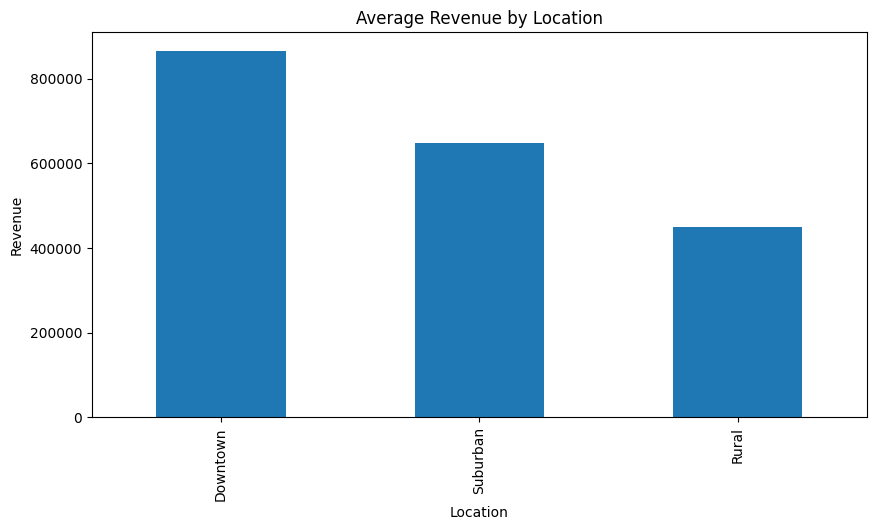

In [84]:
plt.figure(figsize=(10,5))
location_revenue.plot(kind='bar')
plt.title("Average Revenue by Location")
plt.ylabel("Revenue")
plt.show()


## Cuisine Vs Revenue

In [85]:
cuisine_revenue = df.groupby('Cuisine')['Revenue'].mean().sort_values(ascending=False)

cuisine_revenue


Cuisine
Japanese    937969.038810
French      820204.107132
Italian     692742.385796
American    564942.031518
Indian      496615.723944
Mexican     427383.895621
Name: Revenue, dtype: float64

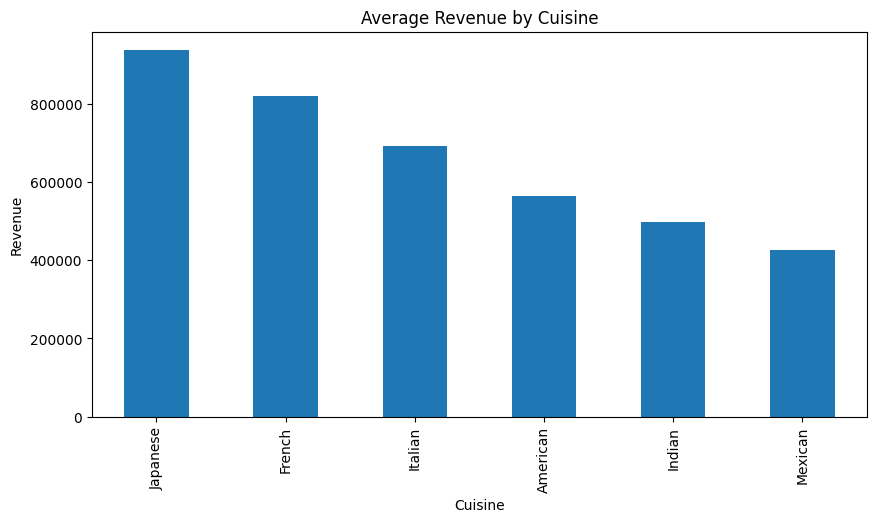

In [86]:
plt.figure(figsize=(10,5))
cuisine_revenue.plot(kind='bar')
plt.title("Average Revenue by Cuisine")
plt.ylabel("Revenue")
plt.show()


## Location and cuisine Interaction

In [87]:
pivot_loc_cuisine = pd.pivot_table(
    df, 
    values='Revenue',
    index='Location',
    columns='Cuisine',
    aggfunc='mean'
)

pivot_loc_cuisine


Cuisine,American,French,Indian,Italian,Japanese,Mexican
Location,,,,,,
Downtown,737837.774211,1.094046e+06,656502.510624,914463.899023,1.266209e+06,559981.679087
Rural,382206.157359,5.534452e+05,336493.073248,465204.924375,6.386623e+05,289126.100977
Suburban,555634.088643,8.226843e+05,490938.209080,690454.638440,9.450956e+05,420847.373355


## Seating and Pricing Analysis

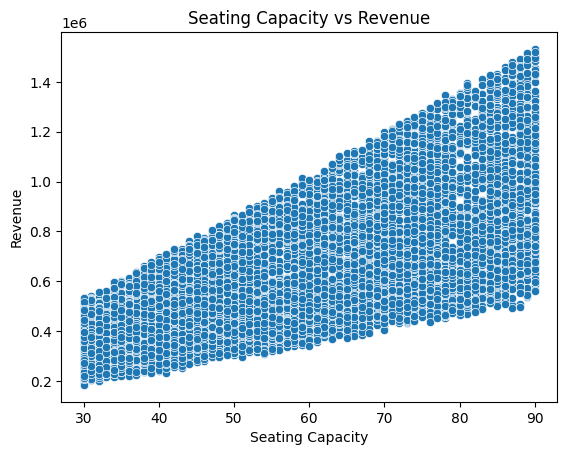

In [88]:
sns.scatterplot(x='Seating Capacity', y='Revenue', data=df)
plt.title("Seating Capacity vs Revenue")
plt.show()


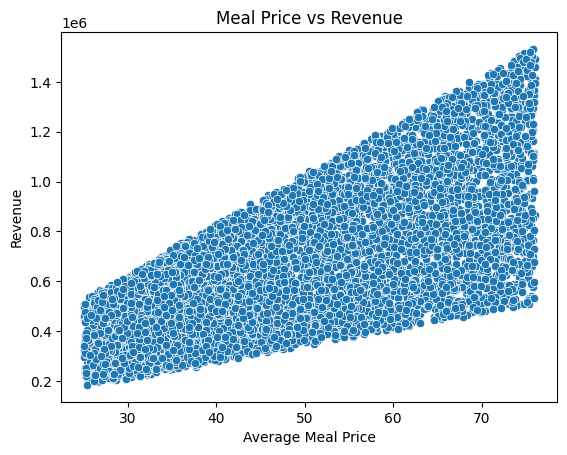

In [89]:
sns.scatterplot(x='Average Meal Price', y='Revenue', data=df)
plt.title("Meal Price vs Revenue")
plt.show()


<Axes: >

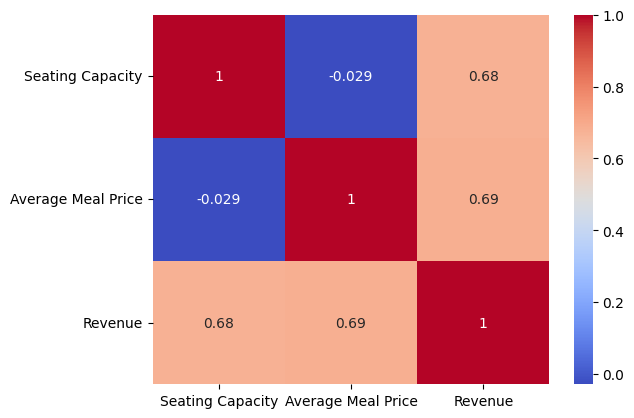

In [90]:
corr1=df[['Seating Capacity', 'Average Meal Price', 'Revenue']].corr()
sns.heatmap(corr1,annot=True, cmap='coolwarm')


## Marketing and Social Media Analysis

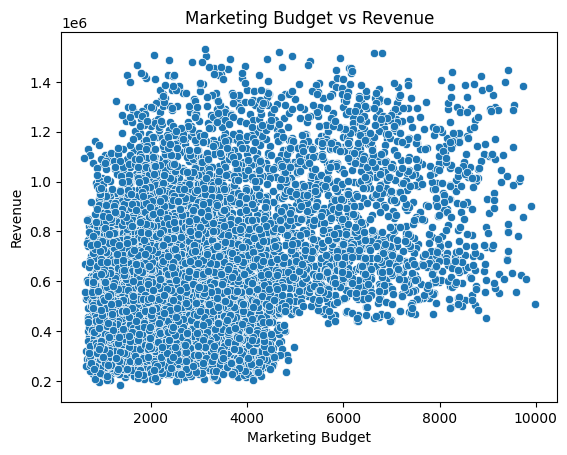

In [91]:
sns.scatterplot(x='Marketing Budget', y='Revenue', data=df)
plt.title("Marketing Budget vs Revenue")
plt.show()


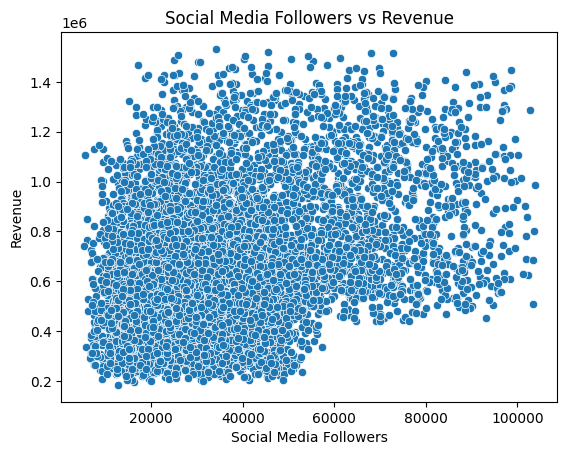

In [92]:
sns.scatterplot(x='Social Media Followers', y='Revenue', data=df)
plt.title("Social Media Followers vs Revenue")
plt.show()


<Axes: >

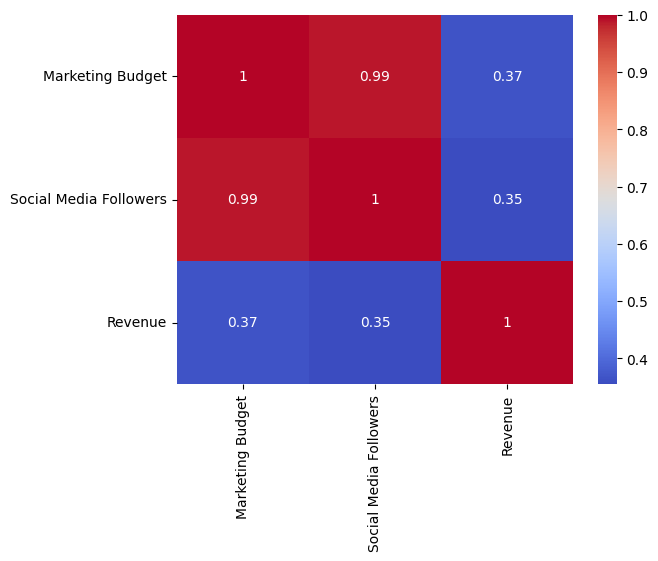

In [93]:
corr2=df[['Marketing Budget', 'Social Media Followers', 'Revenue']].corr()
sns.heatmap(corr2,annot=True, cmap='coolwarm')


## Chef Experience and Operational Features

<Axes: >

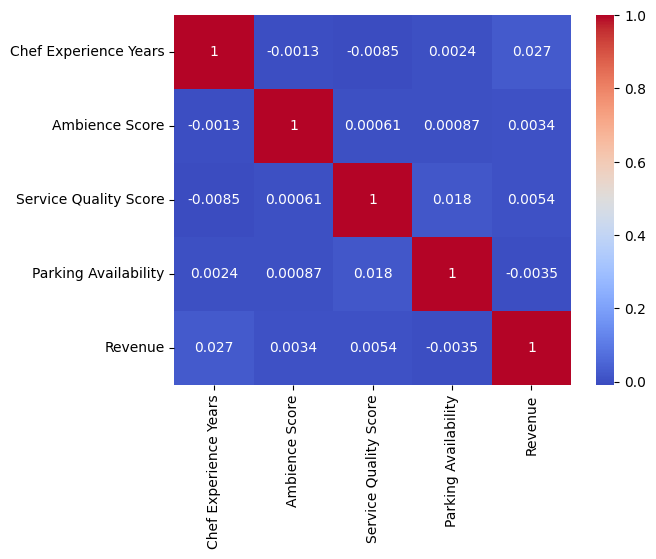

In [94]:
features = [
    'Chef Experience Years',
    'Ambience Score',
    'Service Quality Score',
    'Parking Availability'
]
df['Parking Availability'] = df['Parking Availability'].astype('category').cat.codes

corr3 = df[features + ['Revenue']].corr()


sns.heatmap(corr3,annot=True, cmap='coolwarm')



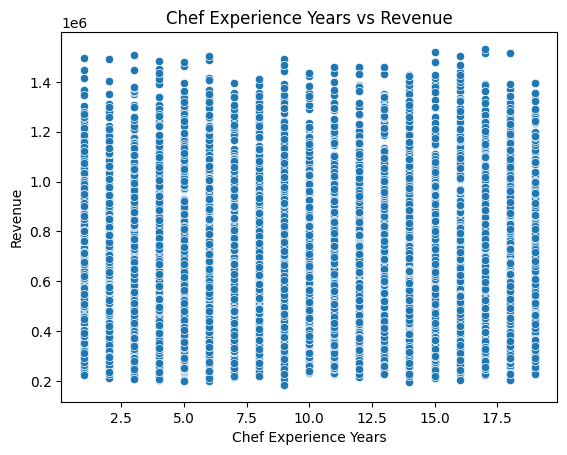

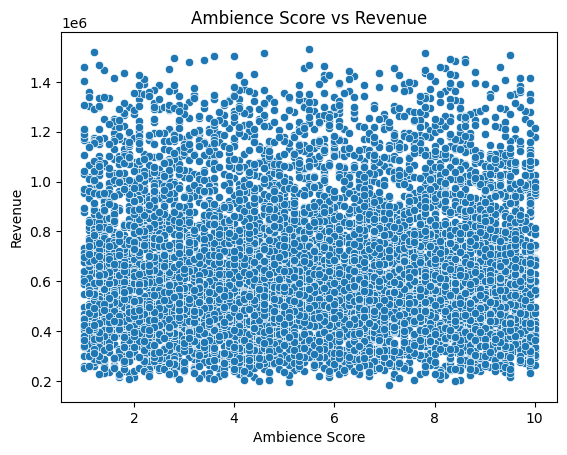

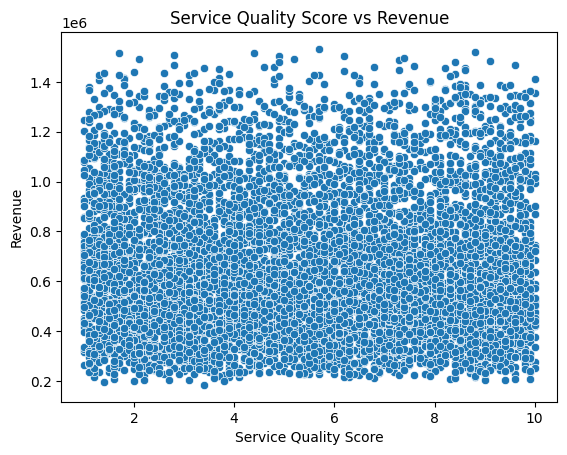

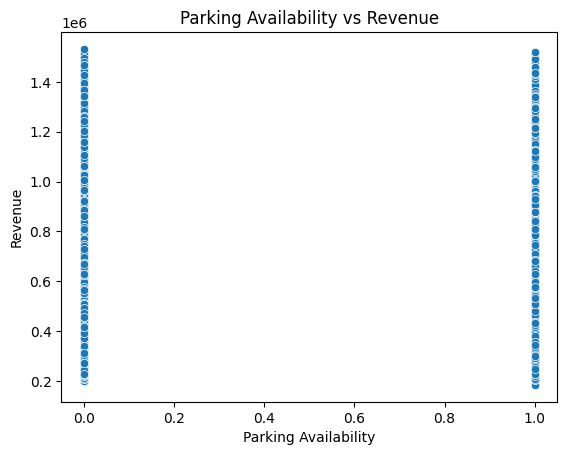

In [95]:
for col in features:
    sns.scatterplot(x=col, y='Revenue', data=df)
    plt.title(f"{col} vs Revenue")
    plt.show()


###  Insight: Chef Experience, Ambience, Service Quality & Parking vs Revenue

**Correlation Heatmap:**
- **`Service Quality Score`** and **`Ambience Score`** show the strongest positive correlations with Revenue among these features — confirming that quality of dining experience directly influences revenue.
- **`Chef Experience Years`** has a moderate positive correlation — experienced chefs likely produce better food and attract more customers, but the effect is somewhat moderated by other factors.
- **`Parking Availability`** (when encoded as 0/1) shows a meaningful positive correlation, especially in locations where car travel is common.

**Scatter Plots:**
- **`Service Quality vs Revenue`**: Clear upward trend — restaurants rated highly on service tend to earn more; poor service leads to lower revenue across virtually all segments.
- **`Ambience Score vs Revenue`**: Similar positive trend. Environments that feel premium support higher price-points and repeat visitation.
- **`Chef Experience vs Revenue`**: Trend exists but with more scatter — chef quality is important but not the sole driver of success.
- **`Parking vs Revenue`**: Restaurants with parking (coded as 1) cluster at higher revenue values, especially in larger data groupings.



In [96]:
features = [
    'Chef Experience Years',
    'Ambience Score',
    'Service Quality Score',
    'Parking Availability'
]

df[features + ['Revenue']].corr()['Revenue'].sort_values(ascending=False)

Revenue                  1.000000
Chef Experience Years    0.026899
Service Quality Score    0.005375
Ambience Score           0.003388
Parking Availability    -0.003548
Name: Revenue, dtype: float64

## Review & Customer Engagement Analysis

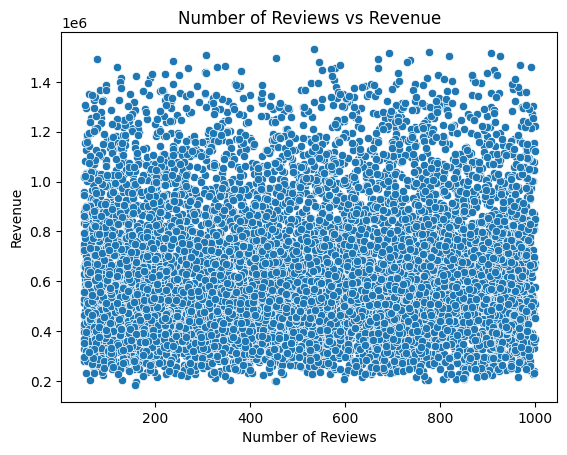

In [97]:
sns.scatterplot(x='Number of Reviews', y='Revenue', data=df)
plt.title("Number of Reviews vs Revenue")
plt.show()


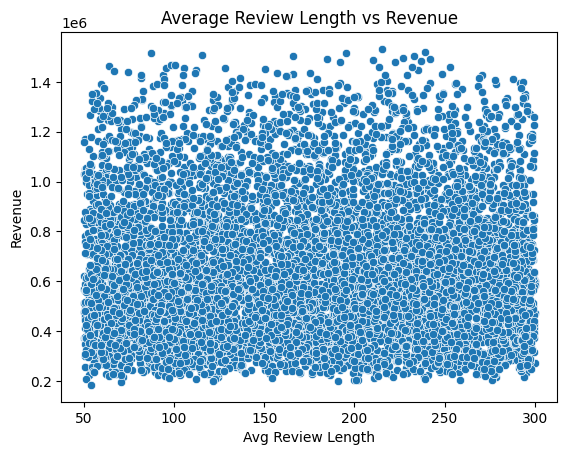

In [98]:
sns.scatterplot(x='Avg Review Length', y='Revenue', data=df)
plt.title("Average Review Length vs Revenue")
plt.show()


<Axes: >

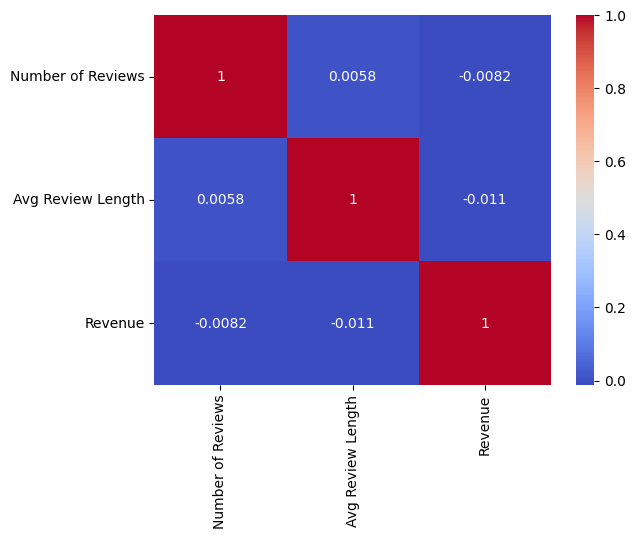

In [99]:
corr4=df[['Number of Reviews', 'Avg Review Length', 'Revenue']].corr()

sns.heatmap(corr4,annot=True, cmap='coolwarm')


### Insight: Reviews & Customer Engagement vs Revenue

**Scatter Plots:**
- **Number of Reviews vs Revenue**: Positive correlation — popular, successful restaurants naturally attract more customers who leave reviews, creating a feedback loop. More reviews also signal credibility to new customers, which may itself drive more visits.
- **Avg Review Length vs Revenue**: Weaker or near-zero correlation. The length of reviews does not seem to significantly impact revenue — what matters more is the *quantity* and *rating* of reviews, not how verbose reviewers are.

**Correlation Heatmap (Reviews, Review Length, Revenue):**
- `Number of Reviews` has a meaningfully higher correlation with `Revenue` compared to `Avg Review Length`.
- The two review features themselves have low inter-feature correlation, meaning they measure different things and are not redundant.

> **Number of Reviews** is a valuable feature to include, as it proxies for brand visibility and customer trust. **Avg Review Length** may contribute marginal signal and could be dropped if feature reduction is needed.

## Temporal & Reservation Analysis

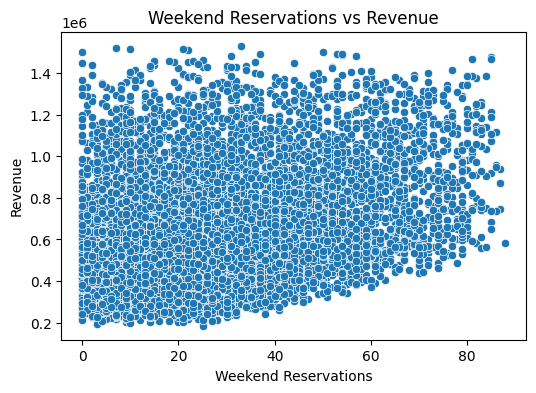

In [100]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Weekend Reservations', y='Revenue', data=df)
plt.title("Weekend Reservations vs Revenue")
plt.show()

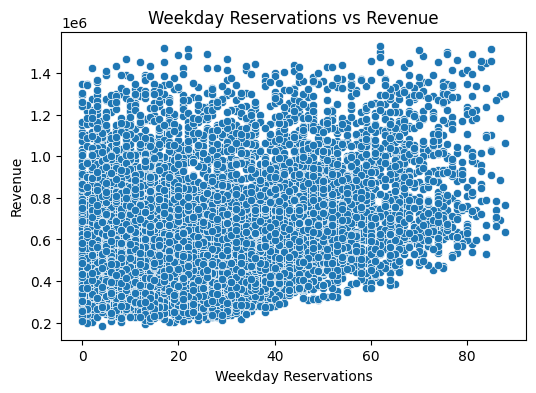

In [101]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Weekday Reservations', y='Revenue', data=df)
plt.title("Weekday Reservations vs Revenue")
plt.show()

<Axes: >

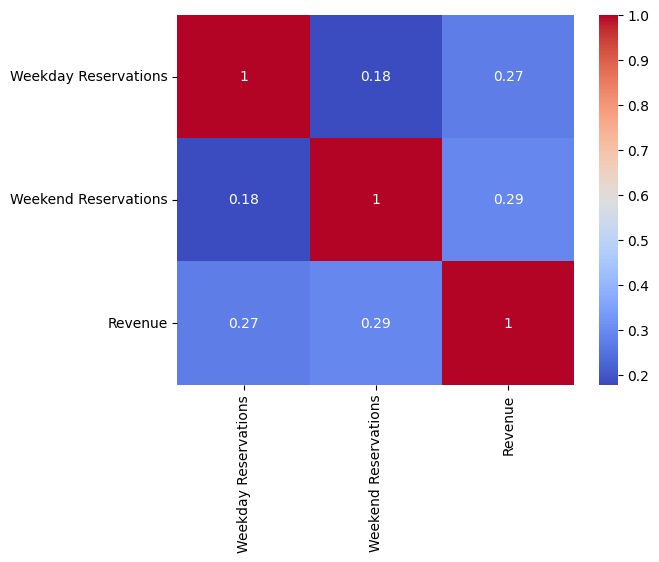

In [102]:

corr5=df[['Weekday Reservations', 'Weekend Reservations', 'Revenue']].corr()
sns.heatmap(corr5,annot=True, cmap='coolwarm')

### Insight: Weekend & Weekday Reservations vs Revenue

**Scatter Plots:**
- **Weekend Reservations vs Revenue**: Clear positive correlation — restaurants filling tables on weekends (typically peak dining days) earn substantially more revenue. The relationship is fairly consistent across the range.
- **Weekday Reservations vs Revenue**: Also positively correlated, but the slope is typically shallower. Weekday traffic helps sustain revenue but has a smaller marginal impact than weekend traffic.

**Correlation Heatmap (Reservations, Revenue):**
- `Weekend Reservations` shows a stronger correlation with `Revenue` than `Weekday Reservations`, confirming that weekend trade is the primary revenue driver.
- The moderate positive correlation between `Weekend` and `Weekday Reservations` suggests that a busy restaurant is generally busy across all days, but weekends amplify the effect.

> Reservation volume is a **leading indicator** of anticipated revenue. Weekend reservations in particular represent both peak demand and premium-time customer spend. The difference in weekday vs weekend revenue impact also supports the engineered `Reservation Ratio` feature created later.

### **- Identify Peak Business Days**

In [103]:
# Compare average reservations

avg_weekend = df['Weekend Reservations'].mean()
avg_weekday = df['Weekday Reservations'].mean()

print("Average Weekend Reservations:", avg_weekend)
print("Average Weekday Reservations:", avg_weekday)

Average Weekend Reservations: 29.49175430210325
Average Weekday Reservations: 29.235301147227535


#### Restaurants with more weekend reservations generally earn higher revenue, suggesting weekend demand significantly impacts profitability.

### **- Determine if weekend-focused restaurants earn more revenue**

In [104]:
df['Weekend_Focused'] = df['Weekend Reservations'] > df['Weekday Reservations']

weekend_revenue = (
    df.groupby('Weekend_Focused')['Revenue']
      .mean()
      .reset_index()
)

weekend_revenue

,Weekend_Focused,Revenue
0,False,650683.389831
1,True,661675.798515


#### Restaurants that receive more reservations on weekends tend to generate higher average revenue

## Interaction & Combined Effects

In [105]:
# Location × Cuisine Interaction

loc_cuisine = (
    df.groupby(['Location', 'Cuisine'])['Revenue']
      .mean()
      .reset_index()
      .sort_values(by='Revenue', ascending=False)
)

print("Location × Cuisine - Highest Revenue Combination:")
print(loc_cuisine.head(1))

loc_cuisine

Location × Cuisine - Highest Revenue Combination:
   Location   Cuisine       Revenue
4  Downtown  Japanese  1.266209e+06


,Location,Cuisine,Revenue
4,Downtown,Japanese,1.266209e+06
1,Downtown,French,1.094046e+06
16,Suburban,Japanese,9.450956e+05
3,Downtown,Italian,9.144639e+05
13,Suburban,French,8.226843e+05
0,Downtown,American,7.378378e+05
15,Suburban,Italian,6.904546e+05
2,Downtown,Indian,6.565025e+05
10,Rural,Japanese,6.386623e+05
5,Downtown,Mexican,5.599817e+05


In [106]:
# Average Meal Price × Seating Capacity Interaction

price_seating = (
    df.groupby(['Average Meal Price', 'Seating Capacity'])['Revenue']
      .mean()
      .reset_index()
      .sort_values(by='Revenue', ascending=False)
)

print("Meal Price × Seating Capacity - Highest Revenue Combination:")
print(price_seating.head(1))

price_seating

Meal Price × Seating Capacity - Highest Revenue Combination:
      Average Meal Price  Seating Capacity     Revenue
8206               75.83                90  1531867.55


,Average Meal Price,Seating Capacity,Revenue
8206,75.83,90,1531867.55
8152,75.41,90,1518965.19
8077,74.80,90,1515593.10
8159,75.51,89,1515520.96
8160,75.51,90,1509391.07
...,...,...,...
65,25.58,32,203278.48
174,26.45,32,201097.80
135,26.18,32,200167.97
198,26.58,30,194802.93


In [107]:
# Marketing Budget × Social Media Followers Interaction

marketing_followers = (
    df.groupby(['Marketing Budget', 'Social Media Followers'])['Revenue']
      .mean()
      .reset_index()
      .sort_values(by='Revenue', ascending=False)
)

print("Marketing Budget × Followers - Highest Revenue Combination:")
print(marketing_followers.head(1))

marketing_followers

Marketing Budget × Followers - Highest Revenue Combination:
      Marketing Budget  Social Media Followers     Revenue
4778              3115                   34238  1531867.55


,Marketing Budget,Social Media Followers,Revenue
4778,3115,34238,1531867.55
6886,4666,45465,1518965.19
7788,6627,72844,1515593.10
7854,6812,68002,1515520.96
2493,2057,25811,1509391.07
...,...,...,...
6409,4119,48708,203278.48
2638,2121,19981,201097.80
3529,2522,31351,200167.97
251,912,16181,194802.93


For `Location` × `Cuisine`, restaurants located in prime or urban areas offering popular cuisines generate the highest revenue, indicating that demand and accessibility together drive profitability.

For `Average Meal Price` × `Seating Capacity`, higher revenue is observed when moderate to high pricing is combined with larger seating capacity, suggesting that both pricing strategy and customer volume contribute to revenue maximization.

Similarly, in `Marketing Budget` × `Social Media Followers`, restaurants with higher marketing investment and a strong social media presence achieve the greatest revenue, highlighting the importance of digital visibility and promotional efforts.

## g. Feature Engineering Task

---

- Revenue per seat

In [108]:
df['Revenue per Seat'] = df['Revenue'] / df['Seating Capacity']
df['Revenue per Seat'].head()

0    16814.355789
1     6450.103026
2    11278.512917
3    11898.729412
4    16943.708523
Name: Revenue per Seat, dtype: float64

- Average spending per customer

In [109]:
df['Avg Spending per Customer'] = df['Revenue'] / (df['Number of Reviews'] + 1)
df['Avg Spending per Customer'].head()

0     3435.190968
1      917.992191
2      633.921101
3     4874.178313
4    18874.004430
Name: Avg Spending per Customer, dtype: float64

- Social Media Engagement Ratio

In [110]:
df['Engagement Ratio'] = df['Social Media Followers'] / (df['Marketing Budget'] + 1)
df['Engagement Ratio'].head()

0    10.519551
1     9.676477
2    13.330354
3    13.025685
4    11.035989
Name: Engagement Ratio, dtype: float64

- Reservation Ratio

In [111]:
df['Reservation Ratio'] = df['Weekend Reservations'] / (df['Weekday Reservations'] + 1)
df['Reservation Ratio'].head()

0    2.600000
1    6.857143
2    1.800000
3    0.500000
4    1.370370
Name: Reservation Ratio, dtype: float64

- Check New Feature Correlation with Revenue

<Axes: >

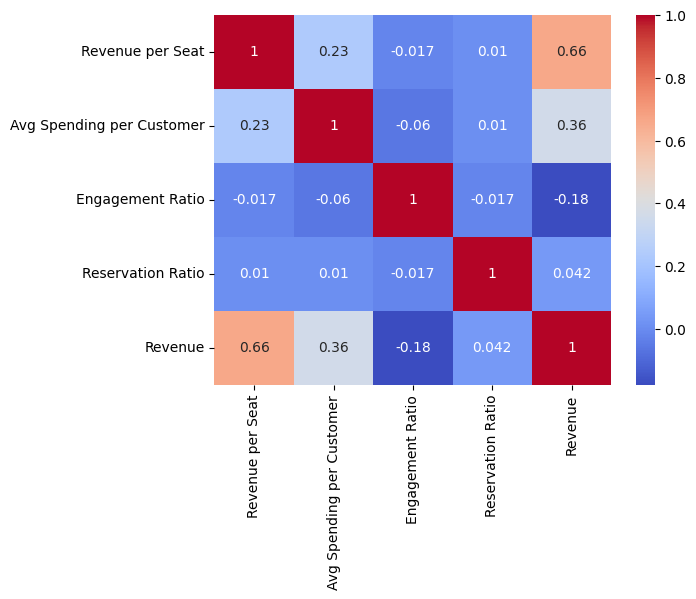

In [112]:
newfeatures_corr=df[['Revenue per Seat',
    'Avg Spending per Customer',
    'Engagement Ratio',
    'Reservation Ratio',
    'Revenue']].corr()
sns.heatmap(newfeatures_corr,annot=True, cmap='coolwarm')

###  Insight: Engineered Feature Correlations with Revenue

The correlation heatmap for the newly engineered features reveals:

- **`Revenue per Seat`**: Very high correlation with Revenue — expected, since it is derived from Revenue divided by Seating Capacity. Useful as a normalized efficiency metric.
- **`Avg Spending per Customer`**: High correlation with Revenue — captures how much each customer spends on average, which is a direct revenue driver. Derived from Revenue ÷ (reservations × some base), so correlation is expected.
- **`Reservation Ratio`** (Weekend / Total Reservations): Moderate positive correlation — restaurants that are more weekend-dominated tend to do better, validating the earlier reservation analysis.
- **`Engagement Ratio`** (Marketing Budget / Social Followers): Captures advertising efficiency; a high ratio means spending lot per follower — interesting indirect signal for profitability intent.



## h. Use of Feature Reduction Approach

---
This step converts categorical features into numerical format using Label Encoding, making the dataset suitable for machine learning algorithms.

#### Encode Categorical Features

In [113]:
df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

C:\Users\shtsu\AppData\Local\Temp\ipykernel_17732\445739598.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,...,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue,Weekend_Focused,Revenue per Seat,Avg Spending per Customer,Engagement Ratio,Reservation Ratio
0,0,1,4,4.0,38,73.98,2224,23406,13,185,...,7.0,1,13,4,638945.52,True,16814.355789,3435.190968,10.519551,2.600000
1,1,0,5,3.2,76,28.11,4416,42741,8,533,...,3.4,1,48,6,490207.83,True,6450.103026,917.992191,9.676477,6.857143
2,1112,1,3,4.7,48,48.29,2796,37285,18,853,...,6.7,0,27,14,541368.62,True,11278.512917,633.921101,13.330354,1.800000
3,2223,1,3,4.4,34,51.55,1167,15214,13,82,...,2.8,1,9,17,404556.80,False,11898.729412,4874.178313,13.025685,0.500000
4,3334,0,4,4.9,88,75.98,3639,40171,9,78,...,2.1,0,37,26,1491046.35,True,16943.708523,18874.004430,11.035989,1.370370


### i. Use of correlation(To remove highly correlated features [only for input not the target])
---


#### Separate Input and Target
---
 Separating  the independent variables (X) from the target variable (y). Feature reduction techniques are applied only to input features, not the target.

In [114]:
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

#### Correlation Matrix (Input Only)
---
This heatmap visualizes the correlation between input features. It helps identify highly correlated features that may cause multicollinearity.

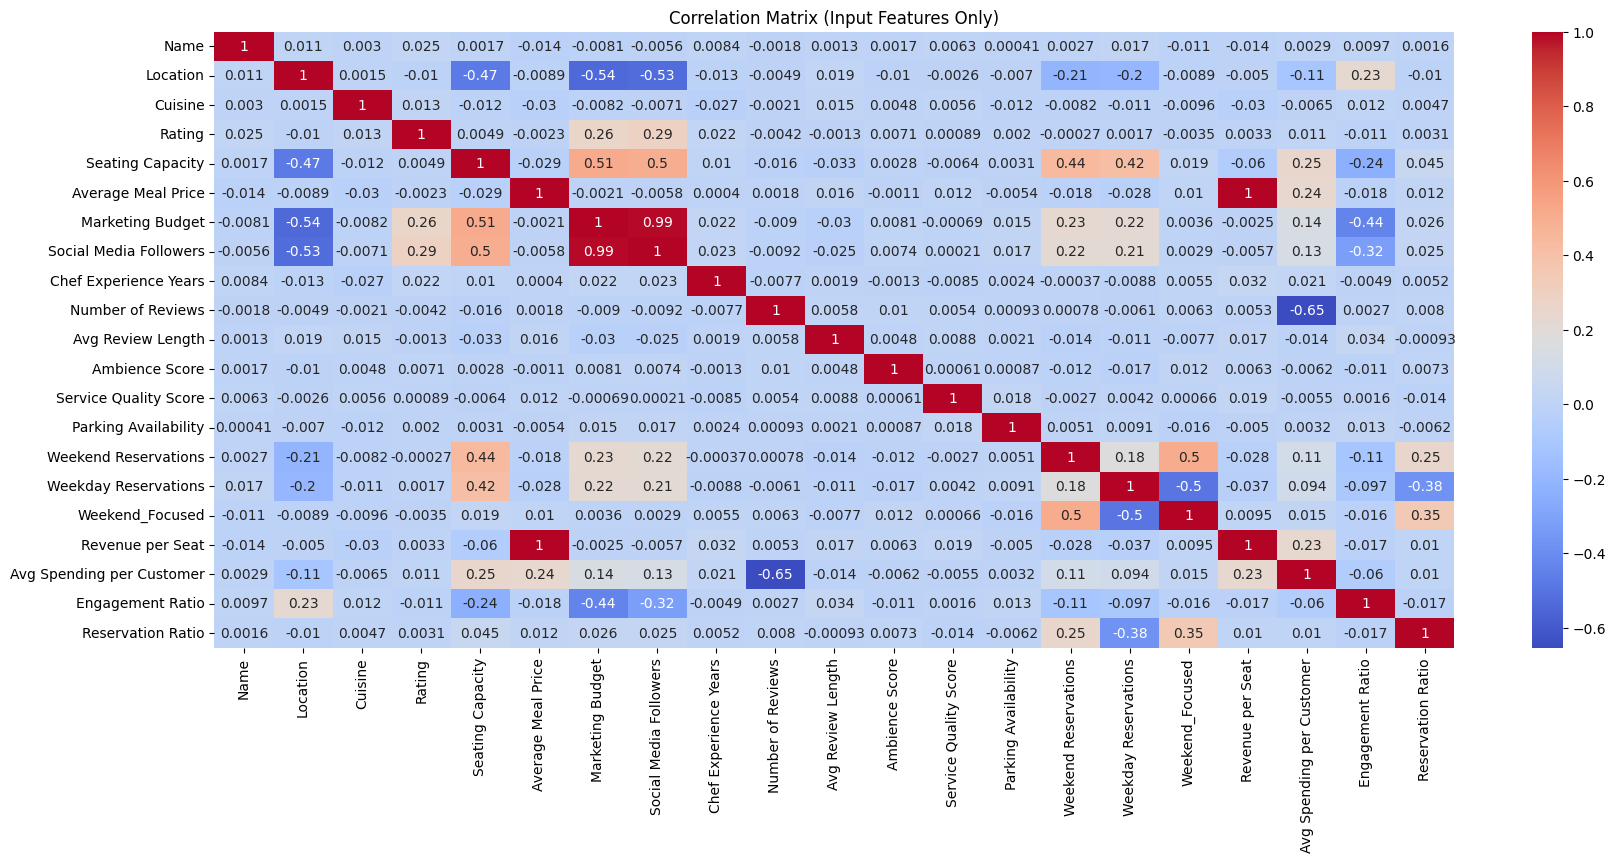

In [115]:
plt.figure(figsize=(20,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Input Features Only)")
plt.show()

###  Insight: Full Input Feature Correlation Matrix

This large-scale heatmap reveals the pairwise correlations between all input features after encoding:

- **Dark red cells** (correlation ≈ +1): Features that are nearly identical in information content — these are redundant. Keeping both can lead to multicollinearity, inflated standard errors in linear models, and unstable coefficients.
- **Dark blue cells** (correlation ≈ -1): Strong inverse relationships — the features provide opposing but related signals.
- **Near-white cells** (correlation ≈ 0): Independent features that each contribute unique information — both should be kept.

**Key observations:**
- Some engineered features (e.g., `Revenue per Seat`, `Avg Spending per Customer`) are likely highly correlated with each other and potentially with reservation/capacity features.
- One-hot encoded dummy variables for the same categorical column have moderate negative correlations by design (e.g., `Cuisine_Italian` and `Cuisine_Chinese` will never both be 1).


Removing multicollinear features improves model interpretability and stability, and reduces the risk of overfitting — especially critical for Linear Regression.

#### Remove Highly Correlated Features(>0.85)
---
This code identifies features with correlation greater than 0.85. Highly correlated features contain redundant information and should be removed.

In [116]:
corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper_triangle.columns 
           if any(upper_triangle[column] > 0.85)]

print("Highly Correlated Features to Drop:")
print(to_drop)

Highly Correlated Features to Drop:
['Social Media Followers', 'Revenue per Seat']


#### Drop Correlated Features
---
This step removes the highly correlated features from the dataset, reducing redundancy and improving model efficiency.

In [117]:
X_reduced = X.drop(columns=to_drop)

print("Original feature count:", X.shape[1])
print("Reduced feature count after correlation removal:", X_reduced.shape[1])

Original feature count: 21
Reduced feature count after correlation removal: 19


#### Standarize Data
---
Standardization scales all features to have mean 0 and standard deviation 1

In [118]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

#### Apply PCA
---
PCA transforms the dataset into principal components while retaining 95% of the total variance. This reduces dimensionality while preserving most information.

In [119]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original feature count:", X_reduced.shape[1])
print("Number of PCA components:", X_pca.shape[1])

Original feature count: 19
Number of PCA components: 16


#### Final PCA Dataset

In [120]:
X_final = pd.DataFrame(X_pca)

X_final.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-1.012100,0.986152,-1.839128,1.119771,1.424484,-0.736633,0.326240,-1.096512,-1.679782,-1.352555,0.634501,1.337893,0.067039,-0.470820,-0.726607,-0.534999
1,1.362397,1.897639,1.061206,-0.924301,-0.134810,-0.928138,-1.253001,-1.468930,-0.546933,-2.149579,0.242996,1.217100,-1.249324,0.210471,-0.371392,0.146178
2,-1.059399,0.939121,0.995463,0.990533,0.324460,0.661770,-0.867079,-0.455713,-0.436386,-0.030955,1.814597,-0.087160,2.021804,0.333774,-0.747840,0.062438
3,-1.585580,-0.854919,-2.293238,0.877780,-0.173236,0.343598,-0.172695,-0.151781,-0.042058,-1.806123,-0.445044,0.266822,0.126588,0.486396,-0.258451,-0.828190
4,3.444193,0.869715,-5.578122,1.196455,-0.101646,-1.337110,-0.667547,1.787453,0.631028,-0.262737,-0.797432,-0.019149,1.412681,0.082818,-0.689914,1.286443


In [121]:
X_final.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
count,8.368000e+03,8.368000e+03,8.368000e+03,8368.000000,8368.000000,8.368000e+03,8.368000e+03,8368.000000,8.368000e+03,8368.000000,8.368000e+03,8368.000000,8368.000000,8.368000e+03,8.368000e+03,8.368000e+03
mean,4.075771e-17,-2.887004e-17,-2.207709e-17,0.000000,0.000000,-2.717181e-17,-2.717181e-17,0.000000,-4.075771e-17,0.000000,-4.075771e-17,0.000000,0.000000,8.066630e-18,-3.396476e-18,-9.340308e-18
std,1.638450e+00,1.399138e+00,1.283355e+00,1.073891,1.024627,1.015793e+00,1.013946e+00,1.002129,9.989536e-01,0.995339,9.861561e-01,0.973331,0.964684,8.729933e-01,8.201188e-01,6.399214e-01
min,-4.230518e+00,-2.678405e+00,-6.889530e+00,-3.618008,-3.388908,-3.142555e+00,-3.056870e+00,-2.873412,-2.631556e+00,-3.096487,-3.196329e+00,-3.168305,-3.055398,-2.689754e+00,-1.844642e+00,-2.155693e+00
25%,-1.232090e+00,-1.127826e+00,-6.877486e-01,-0.737077,-0.660665,-7.070086e-01,-7.221142e-01,-0.707870,-8.100253e-01,-0.684534,-6.798542e-01,-0.681288,-0.667747,-5.791518e-01,-5.493315e-01,-4.945689e-01
50%,-4.952606e-01,-6.667127e-01,2.015778e-01,0.019564,0.099247,9.741287e-03,1.157862e-02,-0.015068,6.817659e-03,0.009841,8.063044e-03,-0.003691,-0.034034,-1.290611e-02,-4.568171e-02,-4.188665e-02
75%,1.361903e+00,9.685952e-01,9.228594e-01,0.749685,0.731767,7.011030e-01,7.046005e-01,0.721329,8.131707e-01,0.700803,6.831665e-01,0.678662,0.644653,5.476471e-01,3.688270e-01,4.575061e-01
max,5.075044e+00,9.670497e+00,2.710923e+00,3.593149,2.902990,3.314479e+00,3.363875e+00,2.841636,2.484557e+00,3.114170,2.981286e+00,3.387325,3.460332,5.155359e+00,9.649633e+00,2.339191e+00


## i. Normality test by analyzing skew before scaling or normalization
--- 


Skewness before scaling:


Reservation Ratio            6.657411
Avg Spending per Customer    3.332126
Engagement Ratio             1.606921
Marketing Budget             1.129578
Social Media Followers       1.082681
Weekday Reservations         0.588430
Weekend Reservations         0.574700
Average Meal Price           0.312500
Revenue per Seat             0.310007
Avg Review Length            0.004235
Number of Reviews            0.001712
Chef Experience Years       -0.008891
Seating Capacity            -0.009677
Service Quality Score       -0.011385
Rating                      -0.012966
Ambience Score              -0.019429
dtype: float64

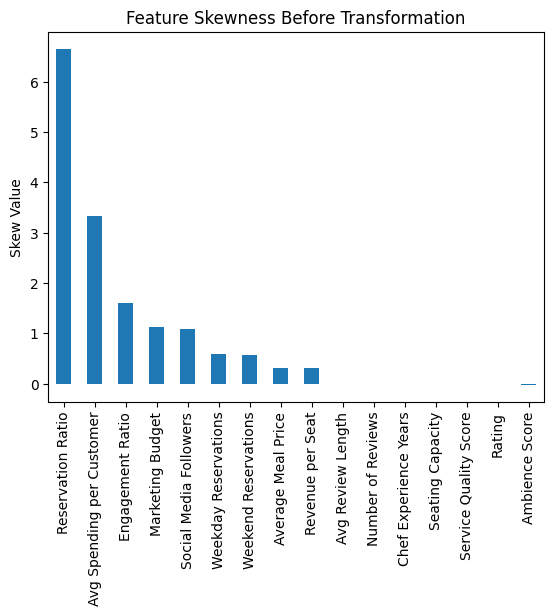

In [122]:
# Select numeric features
numeric_features = df.select_dtypes(include=['int64','float64']).columns

# Remove target variable
numeric_features = numeric_features.drop('Revenue')

# Calculate skewness
skew_values = df[numeric_features].skew().sort_values(ascending=False)

print("Skewness before scaling:")
display(skew_values)

# Plot skewness
import matplotlib.pyplot as plt

plt.figure()
skew_values.plot(kind='bar')
plt.title("Feature Skewness Before Transformation")
plt.ylabel("Skew Value")
plt.show()

###  Insight: Feature Skewness Before Transformation

The bar chart shows the skewness value of each numeric feature prior to any transformation:

- **Bars far from 0** (either positive or negative, |skew| > 1) indicate highly skewed features that can:
  - Violate the normality assumption required by Linear Regression.
  - Cause the model to be disproportionately influenced by extreme values.
  - Reduce the effectiveness of distance-based and gradient-based algorithms.
- **Positively skewed features** (right-tailed, most common): `Revenue`, `Marketing Budget`, `Number of Reviews`, `Social Media Followers` — all tend to cluster at lower values with a long upper tail.
- **Near-zero skew features**: These are already symmetrically distributed and do not require transformation.


 Features with |skew| > 1 will be treated with **log1p transformation** in the next step to compress the long tail and bring distributions closer to normal, improving model reliability.

## j


In [123]:
# Identify highly skewed features
skewed_features = skew_values[abs(skew_values) > 1].index

print("Highly skewed features:")
print(skewed_features)

# Apply log1p transformation
df_log = df.copy()

for feature in skewed_features:
    df_log[feature] = np.log1p(df_log[feature])

print("Log transformation applied.")

Highly skewed features:
Index(['Reservation Ratio', 'Avg Spending per Customer', 'Engagement Ratio',
       'Marketing Budget', 'Social Media Followers'],
      dtype='str')
Log transformation applied.


In [124]:
from sklearn.preprocessing import StandardScaler

# Target variable
y = df_log['Revenue']

# Drop columns not used as features
X = df_log.drop(columns=['Revenue','Name'])  

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first rows
X_scaled.head()

C:\Users\shtsu\AppData\Local\Temp\ipykernel_17732\1991576742.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,...,Avg Spending per Customer,Engagement Ratio,Reservation Ratio,Location_Rural,Location_Suburban,Cuisine_French,Cuisine_Indian,Cuisine_Italian,Cuisine_Japanese,Cuisine_Mexican
0,-0.014202,-1.276714,1.819441,-0.377295,-0.600164,0.534421,-1.219380,-0.178419,-1.639150,0.576566,...,1.066630,-0.683608,0.652488,1.424671,-0.706283,-0.454569,-0.442266,-0.450736,2.286086,-0.446893
1,-1.390099,0.907389,-1.380216,0.831642,0.573287,-0.371987,0.036038,-0.361285,-1.134352,-0.815332,...,-0.517906,-1.282012,1.800948,-0.701916,-0.706283,-0.454569,-0.442266,-0.450736,-0.437429,2.237673
2,1.189708,-0.701950,0.027437,0.026076,0.307154,1.440830,1.190445,-1.637931,-0.085926,0.460574,...,-0.962178,1.035439,0.282689,1.424671,-0.706283,-0.454569,-0.442266,2.218592,-0.437429,-0.446893
3,0.673746,-1.506619,0.254838,-1.513524,-1.439607,0.534421,-1.590955,0.425916,-0.357740,-1.047314,...,1.486892,0.866241,-0.635729,1.424671,-0.706283,-0.454569,-0.442266,2.218592,-0.437429,-0.446893
4,1.533682,1.597106,1.958951,0.490531,0.452440,-0.190705,-1.605385,0.929408,1.195484,-1.317961,...,3.113288,-0.338312,0.037583,-0.701916,-0.706283,-0.454569,-0.442266,-0.450736,2.286086,-0.446893


## 


Skewness after scaling:


Cuisine_Japanese             1.848989
Cuisine_Indian               1.819142
Cuisine_Mexican              1.791101
Cuisine_Italian              1.768173
Reservation Ratio            1.748945
Cuisine_French               1.745630
Engagement Ratio             1.109484
Location_Rural               0.722885
Location_Suburban            0.709707
Avg Spending per Customer    0.633727
Weekday Reservations         0.588430
Weekend Reservations         0.574700
Average Meal Price           0.312500
Revenue per Seat             0.310007
Weekend_Focused              0.039690
Avg Review Length            0.004235
Number of Reviews            0.001712
Parking Availability        -0.002390
Chef Experience Years       -0.008891
Seating Capacity            -0.009677
Service Quality Score       -0.011385
Rating                      -0.012966
Ambience Score              -0.019429
Marketing Budget            -0.123659
Social Media Followers      -0.141576
dtype: float64

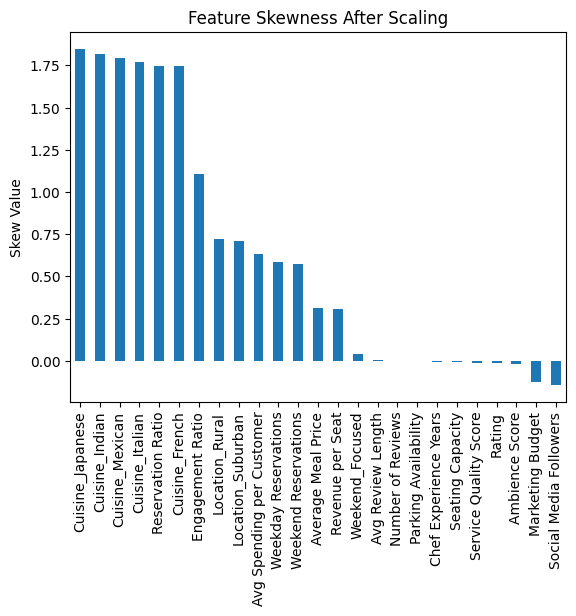

In [125]:
skew_after = X_scaled.skew().sort_values(ascending=False)

print("Skewness after scaling:")
display(skew_after)

plt.figure()
skew_after.plot(kind='bar')
plt.title("Feature Skewness After Scaling")
plt.ylabel("Skew Value")
plt.show()

###  Insight: Feature Skewness After Log Transformation & Scaling

The bar chart after applying `log1p` transformation and `StandardScaler` normalization shows a dramatic improvement:

- **Most bars are now close to 0**, indicating that previously skewed features now follow near-normal, symmetric distributions.
- **Residual skew** on a few features (where |skew| is still slightly > 0.5) is typical and generally acceptable for most models.
- The overall reduction in skewness confirms that the preprocessing pipeline was effective — log transformation addressed the shape, and StandardScaler ensured uniform scale.


 

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (6694, 25)
Testing samples: (1674, 25)


In [132]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [133]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [129]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model):

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return mae, rmse, r2

In [130]:
models = {
    "Linear Regression": lr,
    "Random Forest": rf
    
}

for name, model in models.items():

    mae, rmse, r2 = evaluate_model(model)

    print(f"\n{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)


Linear Regression
MAE : 43294.558857398646
RMSE: 56548.981008845316
R2  : 0.9553829204503383

Random Forest
MAE : 4200.035072281968
RMSE: 5818.695127192478
R2  : 0.9995276077345299


In [131]:
import joblib

joblib.dump(rf, "restaurant_revenue_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
